In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#load dataset
data = pd.read_csv("expenses.csv")

print(data.head())

         Date   Category       Description  Amount Payment_Method
0  2025-01-01       Food         Breakfast     120            UPI
1  2025-01-01  Transport        Bus Ticket      40           Cash
2  2025-01-02       Food             Lunch     180            UPI
3  2025-01-02   Shopping         Groceries     950           Card
4  2025-01-03      Bills  Electricity Bill    1200            UPI


In [15]:
#basic data information
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nDataset Info:")
print(data.info())

Dataset Shape: (30, 5)

Column Names:
Index(['Date', 'Category', 'Description', 'Amount', 'Payment_Method'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            30 non-null     object
 1   Category        30 non-null     object
 2   Description     30 non-null     object
 3   Amount          30 non-null     int64 
 4   Payment_Method  30 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.3+ KB
None


In [16]:
#convert date column
data["Date"] = pd.to_datetime(data["Date"])

In [17]:
#totalexpenses
total_expense = data["Amount"].sum()

print("Total Expense:", total_expense)

Total Expense: 14599


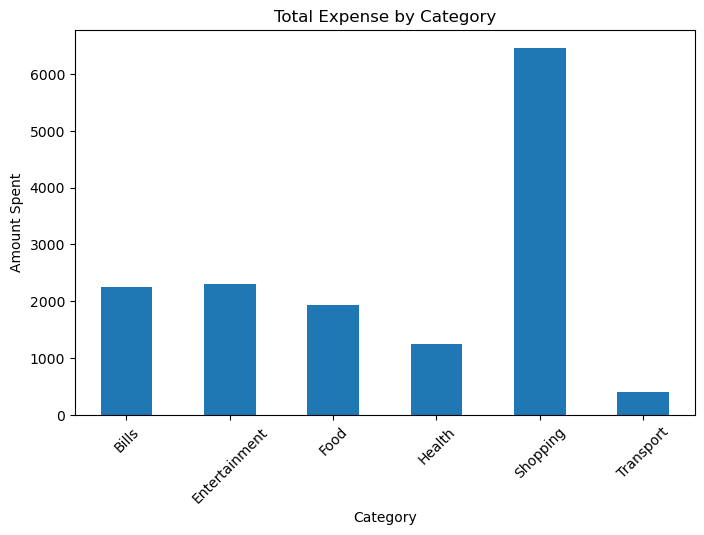

In [18]:
#bar chart
category_expense = data.groupby("Category")["Amount"].sum()

plt.figure(figsize=(8,5))

category_expense.plot(kind="bar")

plt.title("Total Expense by Category")
plt.xlabel("Category")
plt.ylabel("Amount Spent")

plt.xticks(rotation=45)

plt.show()

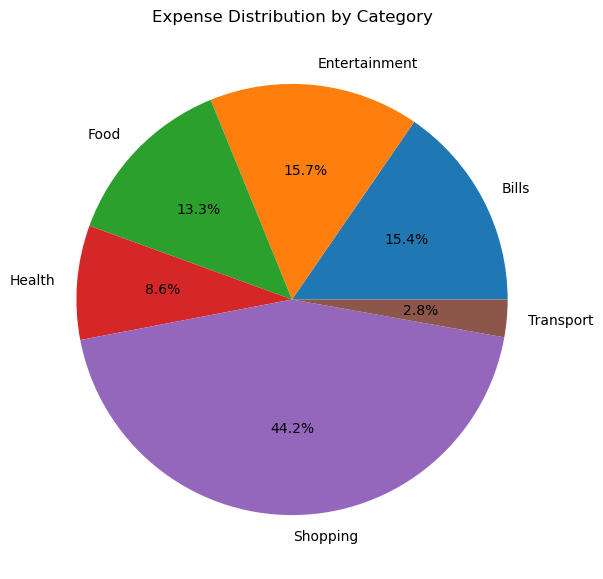

In [19]:
#pie chart
plt.figure(figsize=(7,7))

category_expense.plot(kind="pie", autopct="%1.1f%%")

plt.title("Expense Distribution by Category")

plt.ylabel("")

plt.show()

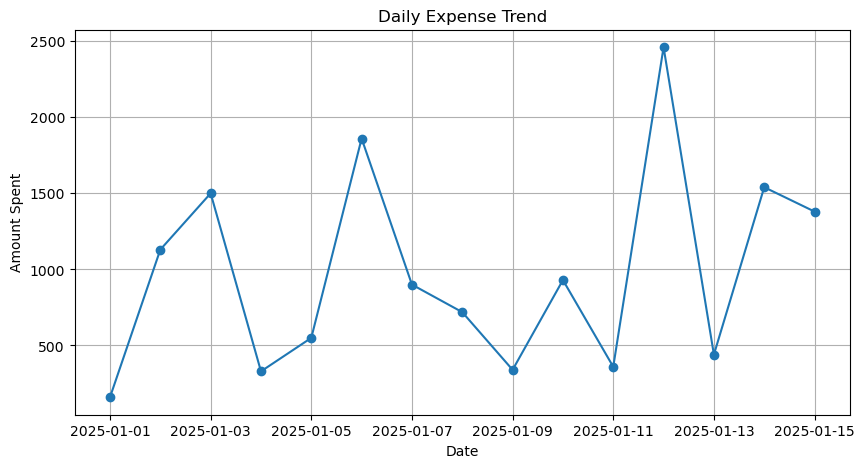

In [20]:
#line graph
daily_expense = data.groupby("Date")["Amount"].sum()

plt.figure(figsize=(10,5))

plt.plot(daily_expense.index, daily_expense.values, marker="o")

plt.title("Daily Expense Trend")

plt.xlabel("Date")
plt.ylabel("Amount Spent")

plt.grid(True)

plt.show()

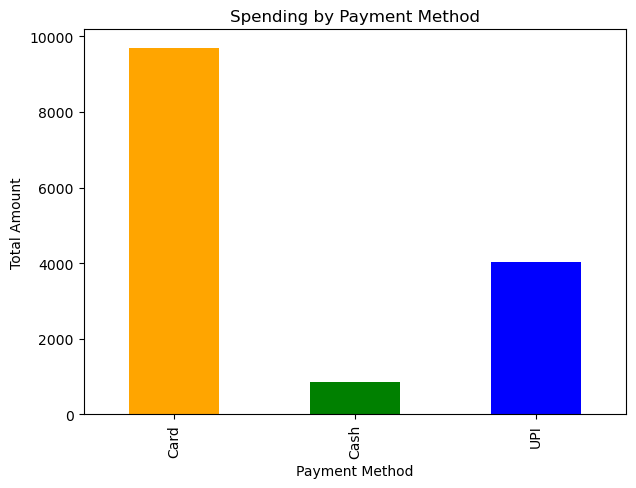

In [21]:
#bar graph
payment_method = data.groupby("Payment_Method")["Amount"].sum()

plt.figure(figsize=(7,5))

payment_method.plot(kind="bar", color=["orange","green","blue"])

plt.title("Spending by Payment Method")

plt.xlabel("Payment Method")
plt.ylabel("Total Amount")

plt.show()

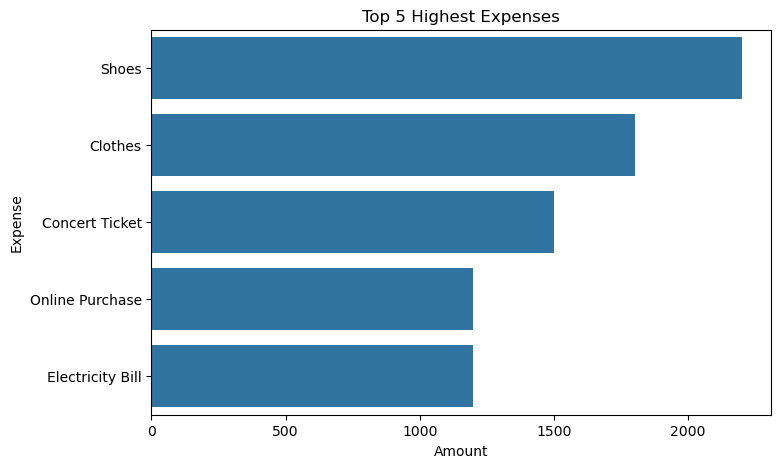

In [22]:
top_expenses = data.sort_values(by="Amount", ascending=False).head(5)

plt.figure(figsize=(8,5))

sns.barplot(x="Amount", y="Description", data=top_expenses)

plt.title("Top 5 Highest Expenses")

plt.xlabel("Amount")
plt.ylabel("Expense")

plt.show()

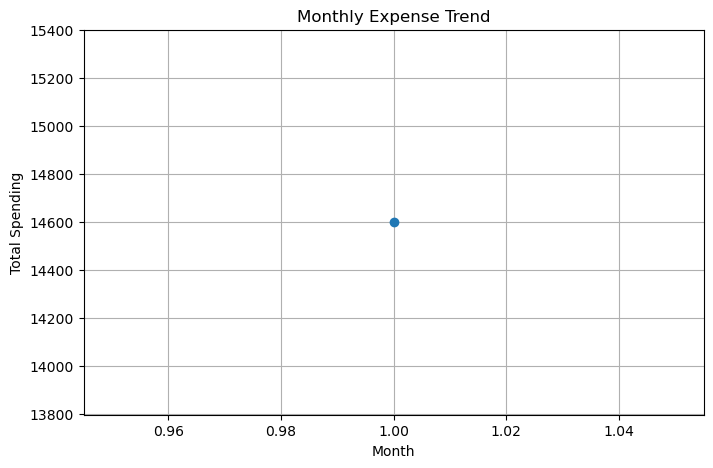

In [23]:
data["Month"] = data["Date"].dt.month

monthly_expense = data.groupby("Month")["Amount"].sum()

plt.figure(figsize=(8,5))

monthly_expense.plot(kind="line", marker="o")

plt.title("Monthly Expense Trend")

plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.grid(True)

plt.show()